In [15]:
# --- Verificar y configurar GPU ---
import tensorflow as tf

gpu_available = tf.config.list_physical_devices('GPU')
print("Dispositivos físicos disponibles:")
for device in gpu_available:
    print(f"  {device}")
if gpu_available:
    print("GPU disponible. Usando:", gpu_available[0].name)
    # Configurar TensorFlow para usar la GPU (opcional, pero puede ser útil)
    tf.config.experimental.set_memory_growth(gpu_available[0], True)
else:
    print("No se encontró GPU. Usando CPU.")

Dispositivos físicos disponibles:
No se encontró GPU. Usando CPU.


# Workshop: NLP para clasificación de Reseñas

# 1. Importar librerias

In [16]:
pip install nltk

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: C:\Users\Usuario\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
# Usa la librería NLTK  https://www.nltk.org/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer # Importar CountVectorizer

# Librerias de Deep Learning (TensorFlow/Keras)
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout
import tensorflow_datasets as tfds ## DATASETS de tensorflow

# Configuracion de visualizacion
sns.set(style="whitegrid")

# Descarga de recursos de lenguaje de NLTK
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# 2. Lectura del dataset (Reseñas de peliculas)

In [18]:
# Cargar dataset IMDB desde TensorFlow
dataset, info = tfds.load(
    'imdb_reviews',
    with_info=True,
    as_supervised=True  # Devuelve (texto, etiqueta)
)

# Separar en entrenamiento y prueba
train_data, test_data = dataset['train'], dataset['test']

# Convertir a listas (más fácil de manipular)
X_train = []
y_train = []

for texto, etiqueta in train_data:
    X_train.append(texto.numpy().decode('utf-8'))
    y_train.append(etiqueta.numpy())

X_test = []
y_test = []

for texto, etiqueta in test_data:
    X_test.append(texto.numpy().decode('utf-8'))
    y_test.append(etiqueta.numpy())

In [19]:
print(len(X_train))
print(len(X_test))

25000
25000


In [20]:
contador = 00
for texto, etiq in dataset['train']:
    print(texto.numpy().decode('utf-8'), etiq.numpy())
    print("\nEtiqueta:", etiq.numpy())  # 0 = negativa, 1 = positiva
    contador += 1
    if contador == 10:
        break

This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it. 0

Etiqueta: 0
I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rubbish. The plot devel

# 3. Pre-Procesamiento del texto

Uso de:

- Tokenizacion: Romper el texto en unidades procesables.
- Normalización: Convertir a minúsculas y eliminación de ruido (signos de puntuación, números).
- StopWords: Eliminación de palabras vacías (artículos, preposiciones) que no aportan significado semántico.
- Stemming: Es un proceso heurístico (basado en reglas simples) que corta los sufijos de las palabras.
  - Elimina terminaciones comunes (como "-ando", "-es", "-mente").
  - Es extremadamente rápido y computacionalmente barato.
  - A menudo genera palabras que no existen en el diccionario (ej: "computadora" -> "comput").
- Lemmatization: Es un proceso morfológico que utiliza un diccionario y análisis gramatical.
  - Analiza el contexto de la palabra (si es verbo, sustantivo, etc.) y busca su forma canónica o "lema" en el diccionario.
  - Siempre devuelve una palabra real y válida (ej: "fui" -> "ir", "mejores" -> "mejor").
  - Requiere más recursos de procesamiento y es más lento que el stemming.
  




In [21]:
df = pd.DataFrame(X_train, columns=['texto'])
df['sentimiento'] = y_train
df['tipo'] = 'entrenamiento'

df_test = pd.DataFrame(X_test, columns=['texto'])
df_test['sentimiento'] = y_test
df_test['tipo'] = 'test'

df = pd.concat([df, df_test], axis=0)

df.head(10)

,texto,sentimiento,tipo
0,This was an absolutely terrible movie. Don't b...,0,entrenamiento
1,"I have been known to fall asleep during films,...",0,entrenamiento
2,Mann photographs the Alberta Rocky Mountains i...,0,entrenamiento
3,This is the kind of film for a snowy Sunday af...,1,entrenamiento
4,"As others have mentioned, all the women that g...",1,entrenamiento
5,This is a film which should be seen by anybody...,1,entrenamiento
6,"Okay, you have:<br /><br />Penelope Keith as M...",0,entrenamiento
7,The film is based on a genuine 1950s novel.<br...,0,entrenamiento
8,I really love the sexy action and sci-fi films...,0,entrenamiento
9,"Sure, this one isn't really a blockbuster, nor...",0,entrenamiento


In [22]:
# Definimos las herramientas de limpieza (usando inglés para consistencia con el preprocesamiento del DataFrame)
stemmer = SnowballStemmer('english')
compiled_regex = re.compile(r'[^a-záéíóúñ\s]')
stop_words_set = set(stopwords.words('english'))
nuevas_stop_words = set(['br','movie','film','one'])
stop_words_set = stop_words_set.union(nuevas_stop_words)

In [23]:
def procesar_tokens_optimizado(texto):
    return " ".join([
        stemmer.stem(palabra)
        for palabra in texto.split()
        if palabra not in stop_words_set
    ])

In [24]:
# Todo el texto pasa a letras minusculas
df['texto_limpio'] = df['texto'].str.lower()

# Solamente nos quedamos con letras dentro del texto. Se eliminan caracteres raros
patron = r'[^a-záéíóúñ\s]'
df['texto_limpio'] = df['texto_limpio'].str.replace(patron, '', regex=True)

# Aplicar la función de procesamiento de tokens definida globalmente
df['texto_limpio'] = df['texto_limpio'].apply(procesar_tokens_optimizado)

In [25]:
df

,texto,sentimiento,tipo,texto_limpio
0,This was an absolutely terrible movie. Don't b...,0,entrenamiento,absolut terribl dont lure christoph walken mic...
1,"I have been known to fall asleep during films,...",0,entrenamiento,known fall asleep film usual due combin thing ...
2,Mann photographs the Alberta Rocky Mountains i...,0,entrenamiento,mann photograph alberta rocki mountain superb ...
3,This is the kind of film for a snowy Sunday af...,1,entrenamiento,kind snowi sunday afternoon rest world go ahea...
4,"As others have mentioned, all the women that g...",1,entrenamiento,other mention women go nude most absolut gorge...
...,...,...,...,...
24995,"Feeling Minnesota is not really a road movie, ...",0,test,feel minnesota realli road that still best cat...
24996,"This is, without doubt, one of my favourite ho...",1,test,without doubt favourit horror film ever realli...
24997,Most predicable movie I've ever seen...extreme...,0,test,predic ive ever seenextrem bore feel like ive ...
24998,It's exactly what I expected from it. Relaxing...,1,test,exact expect relax humor entertain act coupl a...


# 4. ANALISIS EXPLORATORIO (EDA)

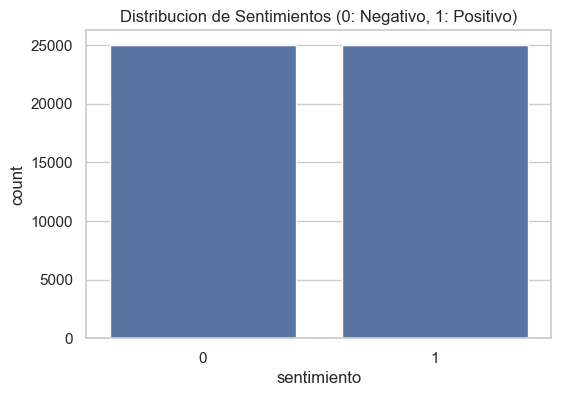

In [26]:
# Visualizacion 1: Balance de clases
plt.figure(figsize=(6, 4))
sns.countplot(x='sentimiento', data=df)
plt.title('Distribucion de Sentimientos (0: Negativo, 1: Positivo)')
plt.show()

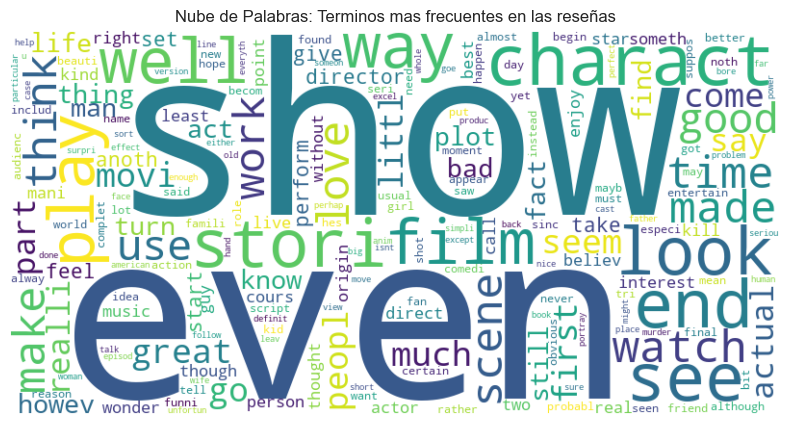

In [27]:
# Visualizacion 2: Nube de Palabras
# Unimos todo el texto limpio en un solo string gigante
texto_completo = " ".join(df['texto_limpio'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(texto_completo)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Nube de Palabras: Terminos mas frecuentes en las reseñas')
plt.show()

# 5. PREPARACION PARA RED NEURONAL

In [55]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Parametros para la vectorizacion
VOCAB_SIZE = 30000  # Numero maximo de palabras unicas a considerar

# Separamos datos (Train / Test)
X_train = df[df['tipo'] == 'entrenamiento']['texto_limpio']
X_test = df[df['tipo'] == 'test']['texto_limpio']
y_train = df[df['tipo'] == 'entrenamiento']['sentimiento']
y_test = df[df['tipo'] == 'test']['sentimiento']

# CountVectorizer: Convierte texto a matrices de frecuencia de terminos
vectorizer = TfidfVectorizer(max_features=VOCAB_SIZE)
vectorizer.fit(X_train)

# Convertir textos a matrices de frecuencia de terminos (y a densas para compatibilidad con Keras)
train_vector = vectorizer.transform(X_train).toarray()
test_vector = vectorizer.transform(X_test).toarray()

print(f"Forma de los datos de entrenamiento (Matriz de conteo densa): {train_vector.shape}")

Forma de los datos de entrenamiento (Matriz de conteo densa): (25000, 30000)


In [56]:
df.head(5)

,texto,sentimiento,tipo,texto_limpio
0,This was an absolutely terrible movie. Don't b...,0,entrenamiento,absolut terribl dont lure christoph walken mic...
1,"I have been known to fall asleep during films,...",0,entrenamiento,known fall asleep film usual due combin thing ...
2,Mann photographs the Alberta Rocky Mountains i...,0,entrenamiento,mann photograph alberta rocki mountain superb ...
3,This is the kind of film for a snowy Sunday af...,1,entrenamiento,kind snowi sunday afternoon rest world go ahea...
4,"As others have mentioned, all the women that g...",1,entrenamiento,other mention women go nude most absolut gorge...


In [57]:
X_train.iloc[0]

'absolut terribl dont lure christoph walken michael ironsid great actor must simpli worst role histori even great act could redeem movi ridicul storylin earli nineti us propaganda piec pathet scene columbian rebel make case revolut maria conchita alonso appear phoni pseudolov affair walken noth pathet emot plug devoid real mean disappoint movi like ruin actor like christoph walken good name could bare sit'

In [58]:
# Visualizar matriz de vectores en un dataframe
df_train = pd.DataFrame(train_vector, columns=vectorizer.get_feature_names_out())
df_train.iloc[:, :30].head()

,aa,aaa,aaargh,aag,aam,aamir,aan,aankhen,aapk,aapkey,...,abbot,abbott,abbrevi,abc,abdic,abduct,abductor,abe,abel,aberr
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# 6. CONSTRUCCION DEL MODELO DE DEEP LEARNING

In [59]:
VOCAB_SIZE = train_vector.shape[1]
VOCAB_SIZE

30000

In [60]:
# Arquitectura secuencial simple para trabajar con vectores de conteo
model = Sequential([
    # Capa de entrada Densa, ya que CountVectorizer produce vectores de conteo
    Dense(1024, activation='relu', input_shape=(VOCAB_SIZE,)),
    Dense(256, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.5), # Dropout para regularización
    # Capa de salida: 1 neurona con Sigmoid (probabilidad entre 0 y 1)
    Dense(1, activation='sigmoid')
])

model.summary()


C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 1024)           │    30,721,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,991,681 (118.22 MB)

 Trainable params: 30,991,681 (118.22 MB)

 Non-trainable params: 0 (0.00 B)

In [61]:
from tensorflow.keras.optimizers import Adam
optimizador = Adam(learning_rate=0.0001)

# Compilacion del modelo
model.compile(loss='binary_crossentropy', optimizer=optimizador, metrics=['accuracy'])

# Entrenamiento
print("\n--- INICIANDO ENTRENAMIENTO ---")
history = model.fit(
    train_vector,
    y_train,
    epochs=10,
    validation_data=(test_vector, y_test),
    verbose=1
)


--- INICIANDO ENTRENAMIENTO ---
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 80ms/step - accuracy: 0.8445 - loss: 0.3878 - val_accuracy: 0.8674 - val_loss: 0.3084
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.9458 - loss: 0.1628 - val_accuracy: 0.8545 - val_loss: 0.3623
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.9791 - loss: 0.0780 - val_accuracy: 0.8405 - val_loss: 0.4983
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 74ms/step - accuracy: 0.9919 - loss: 0.0346 - val_accuracy: 0.8303 - val_loss: 0.6633
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 58s 75ms/step - accuracy: 0.9970 - loss: 0.0149 - val_accuracy: 0.8317 - val_loss: 0.8094
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 72ms/step - accuracy: 0.9991 - loss: 0.0064 - val_accuracy: 0.8309 - val_loss: 0.9335
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step - accuracy: 0.9997 - loss: 0.0032 - val_accuracy: 0.8296 - val_loss: 1.0850
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 57s 73ms/step - a

# 7. EVALUACION Y RESULTADOS

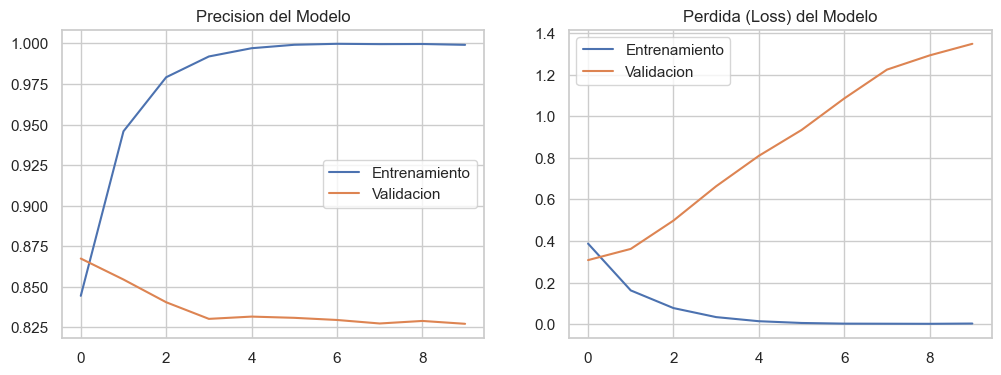

In [62]:
# Graficar perdida y precision
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validacion')
plt.title('Precision del Modelo')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validacion')
plt.title('Perdida (Loss) del Modelo')
plt.legend()

plt.show()


In [67]:
# Prediccion final con un ejemplo nuevo
nuevas_resenas = [
    "The movie is great, awesome and very emotional",
    "I hate this, it's the worst movie I have seen ",
    "This movie had some things good and some bad. Not sure how to feel. Maybe series are better than this loong and boring movies",
    """
    If you were hoping for a nice story about ships reaching their destination, you can still turn back—run away from this movie. James Cameron drags us through an ordeal lasting over three hours in which a maritime voyage goes horribly wrong.
    Here are my main complaints:
    Abysmal damage control: The entire conflict of the second half boils down to the ship filling with water. You’d think that with this production's budget, they would have hired better plumbers or, at the very least, bought more lifeboats.
    Overwhelming special effects: The ship's destruction is so absurdly realistic and massive that it induces anxiety. The music (that screeching violin that won't stop playing while everything sinks) only serves to stress you out further. There isn't a moment of peace; when the water starts rising, the tension becomes so unbearable that you wish you were on dry land.
    A logistically impossible romance: The chemistry between Leonardo DiCaprio and Kate Winslet is so intense that it completely distracts from the naval engineering. They spend half the movie running through flooded corridors, defying class boundaries, and freezing cold—all for a youthful whim.
    Poor use of space: The film's climax is ruined by a serious weight-distribution issue involving a floating wooden door. There was clearly room for both of them, but the movie prefers to shatter your heart into a million pieces rather than be practical.
    Final verdict: A devastating film—visually flawless to the point of nausea, with performances so moving they’ll leave you sobbing uncontrollably like a child. If you want to suffer because of an iceberg and a poorly managed piece of wood, go right ahead. 1/5 stars for the captain, 5/5 for the cinema.
    """
]

# Procesamos las nuevas reseñas usando la función de limpieza y el vectorizador entrenado
nuevas_limpias = [procesar_tokens_optimizado(t) for t in nuevas_resenas]
nuevas_vectorized = vectorizer.transform(nuevas_limpias).toarray()

predicciones = model.predict(nuevas_vectorized)

print("\n--- PRUEBA FINAL CON DATOS NUEVOS ---")
for i, texto in enumerate(nuevas_resenas):
  print(predicciones[i])
  sentimiento = "Positivo" if predicciones[i] > 0.5 else "Negativo"
  confianza = predicciones[i][0] if predicciones[i] > 0.5 else 1 - predicciones[i][0]
  print(f"Texto: '{texto}'")
  print(f"Prediccion: {sentimiento} (Confianza: {confianza:.2f})\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step

--- PRUEBA FINAL CON DATOS NUEVOS ---
[0.99999976]
Texto: 'The movie is great, awesome and very emotional'
Prediccion: Positivo (Confianza: 1.00)

[8.0129104e-07]
Texto: 'I hate this, it's the worst movie I have seen '
Prediccion: Negativo (Confianza: 1.00)

[0.17200938]
Texto: 'This movie had some things good and some bad. Not sure how to feel. Maybe series are better than this loong and boring movies'
Prediccion: Negativo (Confianza: 0.83)

[2.5226377e-10]
Texto: '
    If you were hoping for a nice story about ships reaching their destination, you can still turn back—run away from this movie. James Cameron drags us through an ordeal lasting over three hours in which a maritime voyage goes horribly wrong.
    Here are my main complaints:
    Abysmal damage control: The entire conflict of the second half boils down to the ship filling with water. You’d think that with this production's budget, they would have hired better plumbers or, at the very 

## Guardar modelos en el almacenamiento del PC

In [64]:
import joblib
joblib.dump(model, 'modelo_sentimiento.pkl')
joblib.dump(vectorizer, 'vectorizador.pkl')


['vectorizador.pkl']